# Overview
## Portrait to sketch conditional GAN
* input a portrait image and output a sketch image
* generator input 3 x n x n image (color image) and output 1 x n x n image (mono image)
* discriminator input 1 x n x n image (mono image) and output 0 - 1 (fake/real)

**References**
*   [How to Develop a Pix2Pix GAN for Image-to-Image Translation](https://machinelearningmastery.com/how-to-develop-a-pix2pix-gan-for-image-to-image-translation/)
*   [How to Develop a Conditional GAN (cGAN) From Scratch](https://machinelearningmastery.com/how-to-develop-a-conditional-generative-adversarial-network-from-scratch/)
* https://www.tensorflow.org/tutorials/generative/pix2pix

In [1]:
pip install natsort

  Obtaining dependency information for natsort from https://files.pythonhosted.org/packages/ef/82/7a9d0550484a62c6da82858ee9419f3dd1ccc9aa1c26a1e43da3ecd20b0d/natsort-8.4.0-py3-none-any.whl.metadata
Note: you may need to restart the kernel to use updated packages.


In [2]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import random
from natsort import natsorted, os_sorted, ns
import time
import datetime
import random

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

data_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        data_paths.append(os.path.join(dirname, filename))
print("total number of data:",len(data_paths))

/kaggle/input
/kaggle/input/cuhk-face-sketch-database-cufs
/kaggle/input/cuhk-face-sketch-database-cufs/sketch_points
/kaggle/input/cuhk-face-sketch-database-cufs/photos
/kaggle/input/cuhk-face-sketch-database-cufs/cropped_sketch
/kaggle/input/cuhk-face-sketch-database-cufs/sketch
/kaggle/input/cuhk-face-sketch-database-cufs/photo_points
/kaggle/input/cuhk-face-sketch-database-cufs/sketches
/kaggle/input/cuhk-face-sketch-database-cufs/photo
/kaggle/input/cuhk-face-sketch-database-cufs/original_sketch
total number of data: 5716


In [4]:
# Check if GPU is available
if tf.test.is_gpu_available():
    print("GPU is available")
    # Set TensorFlow to use GPU
    tf.config.set_visible_devices(tf.config.list_physical_devices('GPU'), 'GPU')
    logical_devices = tf.config.list_logical_devices('GPU')
    print(len(logical_devices), "GPU(s) are available.")
else:
    print("GPU is NOT available")
    # If GPU is not available, use CPU
    tf.config.set_visible_devices(tf.config.list_physical_devices('CPU'), 'CPU')


GPU is available
1 GPU(s) are available.


# Load the image dataset
* Load the portrait photos and sketches
* Pair the portrait photos with its corresponding sketches 

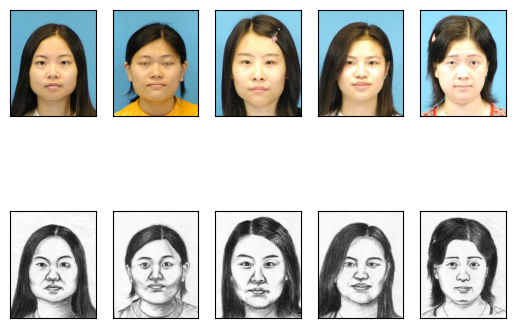

In [5]:
portrait_path = r"/kaggle/input/cuhk-face-sketch-database-cufs/photos"
sketches_path = r"/kaggle/input/cuhk-face-sketch-database-cufs/sketches"

portrait_imgname = os.listdir(portrait_path)
sketches_imgname = os.listdir(sketches_path)

#make the portrait paired to sketch
portrait_imgname = natsorted(portrait_imgname, alg=ns.IGNORECASE)
sketches_imgname = natsorted(sketches_imgname, alg=ns.IGNORECASE)

portrait_imgs = [portrait_path+"/"+imgname for imgname in portrait_imgname]
sketches_imgs = [sketches_path+"/"+imgname for imgname in sketches_imgname]

imgnum = 5
imgrow = 2
for i in range(imgnum):
    image = Image.open(portrait_imgs[i])
    image2 = Image.open(sketches_imgs[i])
#     if (i==0):
#         print(np.array(image).shape) #color
#         print(np.array(image2).shape) #grey
    
    ax = plt.subplot(imgrow,imgnum,i+1)
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    
    ax = plt.subplot(imgrow,imgnum,i+imgnum+1)
    plt.imshow(image2, cmap="gray")
    plt.xticks([])
    plt.yticks([])

## Data preprocessing
* resize the image into NxN
* normalize the image from (0 to 255) to (-1 to 1)
* separate into train and test set

In [6]:

def load(image_path):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image,channels=IN_CHANNEL)
    image = tf.cast(image, tf.float32)
    return image

def resize(image, height, width):
  image = tf.image.resize(image, [height, width],
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  return image

def normalize(image):
  image = (image/ 127.5) - 1
  return image


#data augmentation
def flip(image):
    image = tf.image.flip_left_right(image)
    return image

adjustment_seed = 1
random.seed(adjustment_seed)
def random_adjustment(image1,image2):
    rand_bright = random.uniform(1,5)
    rand_contrast = random.uniform(1,2)
    
    image1 = tf.image.adjust_brightness(image1,delta=rand_bright)
    image2 = tf.image.adjust_brightness(image2,delta=rand_bright)
    
    image1 = tf.image.adjust_contrast(image1,contrast_factor=rand_contrast)
    image2 = tf.image.adjust_contrast(image2,contrast_factor=rand_contrast)
    
    image1 = tf.cast(image1, tf.float32)
    image2 = tf.cast(image2, tf.float32)
    
    return image1,image2\

IMG_SIZE = 256

#the in channel and out channel has to be the same for tf batch
#even though the generated image is greyscale (1channel), it is converted into RGB (3channels)
IN_CHANNEL = 3
OUT_CHANNEL = IN_CHANNEL

TRAIN_BATCH = 4

In [7]:
#temp_dataset = tf.data.Dataset.from_tensor_slices([1,2,3,4,5,6,7,8,9,10])
# temp_dataset = tf.data.Dataset.from_tensor_slices([[1,2],[3,4],[5,6],[7,8],[9,10]])
# for temp_data in temp_dataset:
#     print(temp_data)
# temp_dataset = temp_dataset.batch(3)
# for temp_data in temp_dataset:
#     print(temp_data)
    
tempsize = 4
imgs = []
for i in range(tempsize):
    img1 = load(portrait_imgs[i])
    img1 = resize(img1,IMG_SIZE,IMG_SIZE)
    img1 = normalize(img1)

    img2 = load(sketches_imgs[i])
    img2 = resize(img2,IMG_SIZE,IMG_SIZE)
    img2 = normalize(img2)
    imgs.append(tf.convert_to_tensor([img1,img2]))
print(tf.convert_to_tensor(imgs).shape)

(4, 2, 256, 256, 3)


images in trainset: 534
trainset len: 134


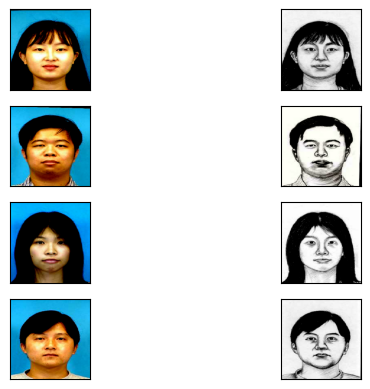

In [8]:
BUFFER_SIZE = len(portrait_imgs)
TRAIN_SIZE = int(BUFFER_SIZE*0.95)
TEST_SIZE =  int(BUFFER_SIZE - TRAIN_SIZE)


train_imgs_idx = []
test_imgs_idx = []

train_imgs = []
test_imgs = []

for i in range(BUFFER_SIZE):
        portrait_img = load(portrait_imgs[i])
        portrait_img = resize(portrait_img,IMG_SIZE,IMG_SIZE)
        
        sketch_img = load(sketches_imgs[i])
        sketch_img = resize(sketch_img,IMG_SIZE,IMG_SIZE)
        
        #data augmentation
        portrait_img2 = flip(portrait_img)
        portrait_img2 = normalize(portrait_img2)
        
        sketch_img2 = flip(sketch_img)
        sketch_img2 = normalize(sketch_img2)
        
        portrait_img3,sketch_img3 = random_adjustment(portrait_img,sketch_img)
        portrait_img3 = normalize(portrait_img3)
        sketch_img3 = normalize(sketch_img3)
        
        portrait_img = normalize(portrait_img)
        sketch_img = normalize(sketch_img)
    
        if (i<TRAIN_SIZE):
            train_imgs.append(tf.convert_to_tensor([portrait_img,sketch_img]))
            train_imgs.append(tf.convert_to_tensor([portrait_img2,sketch_img2]))
            train_imgs.append(tf.convert_to_tensor([portrait_img3,sketch_img3]))
#             train_imgs_idx.append(i)
        else:
            test_imgs.append(tf.convert_to_tensor([portrait_img,sketch_img]))
            test_imgs.append(tf.convert_to_tensor([portrait_img2,sketch_img2]))
            test_imgs.append(tf.convert_to_tensor([portrait_img3,sketch_img3]))
#             test_imgs_idx.append(i)

# def dataset_process(idx):
#     #print(idx) #idx type is not int but Tensor
#     #portrait_img = load(portrait_imgs[idx])
#     portrait_img = load(tf.gather(portrait_imgs, idx))
#     portrait_img = resize(portrait_img,IMG_SIZE,IMG_SIZE)
#     portrait_img = normalize(portrait_img)

#     #sketch_img = load(sketches_imgs[idx])
#     sketch_img = load(tf.gather(sketches_imgs, idx))
#     sketch_img = resize(sketch_img,IMG_SIZE,IMG_SIZE)
#     sketch_img = normalize(sketch_img)
    
#     return portrait_img,sketch_img

# train_set = tf.data.Dataset.from_tensor_slices(train_imgs_idx)
train_set = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(train_imgs))
# train_set = train_set.map(dataset_process,num_parallel_calls=tf.data.AUTOTUNE)
print("images in trainset:",len(train_set))
train_set = train_set.shuffle(len(train_set))
#the image shown might be weird as normalized to -1 to 1
for i,data in enumerate(train_set):
    if (i>=imgnum):
        break
#     ax = plt.subplot(imgrow,imgnum,i+1)
#     plt.imshow(data[0])
#     plt.xticks([])
#     plt.yticks([])
    
#     ax = plt.subplot(imgrow,imgnum,i+imgnum+1)
#     plt.imshow(data[1], cmap="gray")
#     plt.xticks([])
#     plt.yticks([])
    
train_set = train_set.batch(TRAIN_BATCH)
print("trainset len:",len(train_set))

for batch_items in train_set.repeat().take(1): #taking 1 batch to show
    #print(batch_items.shape)
    temp_num_of_img_pair = len(batch_items)
    idx = 1
    for image_pair in batch_items:
        #print(image_pair.shape)
        input_image, target_image = image_pair
        
        ax = plt.subplot(temp_num_of_img_pair,2,idx)
        plt.imshow(input_image)
        plt.xticks([])
        plt.yticks([])
        idx+=1
        
        ax = plt.subplot(temp_num_of_img_pair,2,idx)
        plt.imshow(target_image, cmap="gray")
        plt.xticks([])
        plt.yticks([])
        idx+=1

# test_set = tf.data.Dataset.from_tensor_slices(test_imgs_idx)
test_set = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(test_imgs))
# test_set = test_set.map(dataset_process,num_parallel_calls=tf.data.AUTOTUNE)
test_set = test_set.shuffle(len(test_set))


# Generator
* U-Net architecture (which consist of encoder and decoder)
* Encoder
    * keep downsizing the image size but will have more features(channels)
    * will obtain the features from the image 
* Decoder
    * keep upsizing the image size but will have less features(channels)
    * will combine all the features and eventually from the desired image

In [9]:
#the output image size will always be input image size/strides as padding="same"
def downsample(feature, kernel, apply_batchnorm=False):
    result = tf.keras.Sequential()
    
    if apply_batchnorm:
        result.add(
            tf.keras.layers.Conv2D(feature, kernel, strides=2, padding='same', use_bias=False))
        result.add(tf.keras.layers.BatchNormalization())
    else:
        result.add(
            tf.keras.layers.Conv2D(feature, kernel, strides=2, padding='same'))

    result.add(tf.keras.layers.LeakyReLU())

    return result

#the output image size will always be input image size/strides as padding="same"
def upsample(feature, kernel, apply_batchnorm=False, apply_dropout=False, dropout=0):
    result = tf.keras.Sequential()

    if apply_batchnorm:
        result.add(
            tf.keras.layers.Conv2DTranspose(feature, kernel, strides=2, padding='same', use_bias=False))
        result.add(tf.keras.layers.BatchNormalization())
    else:
        result.add(
            tf.keras.layers.Conv2DTranspose(feature, kernel, strides=2, padding='same'))
        
    if apply_dropout:
          result.add(tf.keras.layers.Dropout(dropout))
            
    result.add(tf.keras.layers.LeakyReLU())

    return result

(1, 128, 128, 12)
(1, 256, 256, 3)


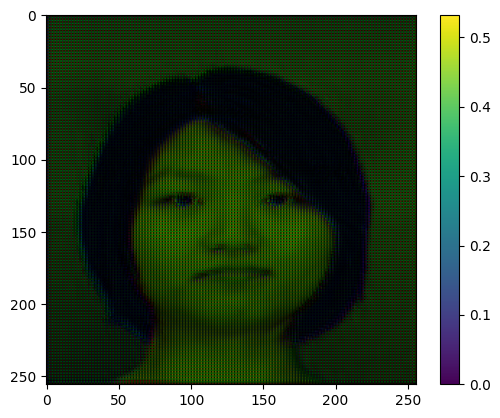

In [10]:
input_shape = (1, IMG_SIZE, IMG_SIZE, IN_CHANNEL) #1 represents batch size
x = tf.random.normal(input_shape)

inp = data[0]
x = inp[tf.newaxis, ...]
y = downsample(12,4)(x) 
print(y.shape)

x_restored = upsample(OUT_CHANNEL,4)(y) 
print(x_restored.shape)
plt.imshow(x_restored[0, ...])
plt.colorbar()


In [11]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, IN_CHANNEL])
    
    #the comment below is considering IMG_SIZE=256
    down_stack = [
        downsample(64, 4),  # (batch_size, 128, 128, 64)
        downsample(128, 4),  # (batch_size, 64, 64, 128)
        downsample(256, 4),  # (batch_size, 32, 32, 256)
        downsample(512, 4),  # (batch_size, 16, 16, 512)
        #downsample(512, 4),  # (batch_size, 8, 8, 512)
        #downsample(512, 4),  # (batch_size, 4, 4, 512)
        #downsample(512, 4),  # (batch_size, 2, 2, 512)
        #downsample(512, 4),  # (batch_size, 1, 1, 512)
    ]
    #the up_stack does not include the last layer of forming the desired image
    up_stack = [
        #upsample(512, 4), #, apply_dropout=True, dropout=0.3),  # (batch_size, 2, 2, 512)
        #upsample(512, 4), #, apply_dropout=True, dropout=0.3),  # (batch_size, 4, 4, 512)
        #upsample(512, 4), #, apply_dropout=True, dropout=0.3),  # (batch_size, 8, 8, 512)
        #upsample(512, 4),  # (batch_size, 16, 16, 512)
        upsample(256, 4),  # (batch_size, 32, 32, 256)
        upsample(128, 4),  # (batch_size, 64, 64, 128)
        upsample(64, 4),  # (batch_size, 128, 128, 64)
    ]
    last = tf.keras.layers.Conv2DTranspose(OUT_CHANNEL, 4,
                                           strides=2,
                                           padding='same',
                                           activation='tanh')  # (batch_size, 256, 256, channel)
    
    x = inputs
    
    #downsampling
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])
    
    #upsampling (with skip connection)
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        
    x = last(x)
    
    return tf.keras.Model(inputs=inputs, outputs=x)


In [12]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64,to_file='generator.png')
generator.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 sequential_2 (Sequential)   (None, 128, 128, 64)         3136      ['input_1[0][0]']             
                                                                                                  
 sequential_3 (Sequential)   (None, 64, 64, 128)          131200    ['sequential_2[0][0]']        
                                                                                                  
 sequential_4 (Sequential)   (None, 32, 32, 256)          524544    ['sequential_3[0][0]']        
                                                                                              

([], [])

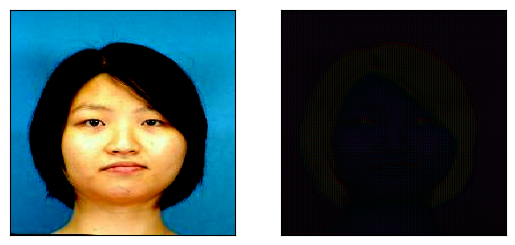

In [13]:
# temp_img_num = 3
# for step, (input_image, target) in train_set.repeat().take(temp_img_num).enumerate():
#     #print((step*2)+1)
#     #print((step*2)+2)
#     ax = plt.subplot(temp_img_num,2,(int(step)*2)+1)
#     plt.imshow(input_image[0])
#     plt.xticks([])
#     plt.yticks([])
    
#     gen_output = generator(input_image[0][tf.newaxis, ...], training=False)
#     ax = plt.subplot(temp_img_num,2,(int(step)*2)+2)
#     plt.imshow(gen_output[0,...], cmap="gray")
#     plt.xticks([])
#     plt.yticks([])
#     #break

inp = data[0]
gen_output = generator(inp[tf.newaxis, ...], training=False)
ax = plt.subplot(1,2,1)
plt.imshow(inp)
plt.xticks([])
plt.yticks([])
ax = plt.subplot(1,2,2)
plt.imshow(gen_output[0, ...])
plt.xticks([])
plt.yticks([])

## Generator loss
* the GAN loss is the binary cross entropy loss, which is defined by the difference between the label of generated image with label 1 (1 indicates the image is real)
* The GAN loss represents how real is the generated image
* Other than that, L1 loss is introduced
* L1 loss represents the Mean Absolute Error (MAE) between generated image and target image 

In [14]:
LAMBDA = 100

In [15]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [16]:
def generator_loss(disc_generated_output, gen_output, target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  # Mean absolute error
  l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

  total_gen_loss = gan_loss + (LAMBDA * l1_loss)

  return total_gen_loss, gan_loss, l1_loss

# Discriminator
* PatchGAN
    * it will takes the patch of image to identify if the patch of generated image is real or fake

**References**
* https://serp.ai/patchgan/

In [17]:
def Discriminator():
    inp = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, IN_CHANNEL], name='input_image')
    tar = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, OUT_CHANNEL], name='target_image')
    
    x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, total channels)
    
    #get the features from the image
    x = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
    x = downsample(128, 4)(x)  # (batch_size, 64, 64, 128)
    x = downsample(256, 4)(x)  # (batch_size, 32, 32, 256)
    
    #make the output image NxN with 1 channel
    x = tf.keras.layers.Conv2D(1, 1, strides=1, padding='valid')(x)  # (batch_size, size, size, 1)
    return tf.keras.Model(inputs=[inp, tar], outputs=x)
    

In [18]:
input_shape = (1, 32, 32, 256) #1 represents batch size
x = tf.random.normal(input_shape)
print(x.shape)

y = tf.keras.layers.Conv2D(1, 1, strides=1, padding='valid')(x)
print(y.shape)

(1, 32, 32, 256)
(1, 32, 32, 1)


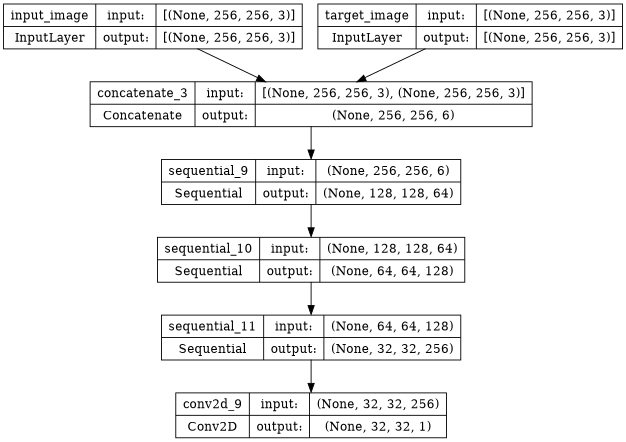

In [19]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64,to_file='discriminator.png')

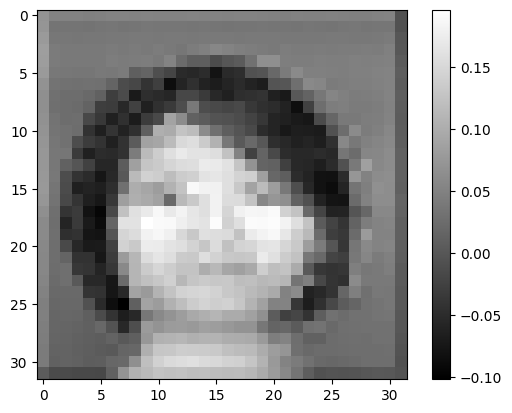

In [20]:
inp = data[0]
disc_out = discriminator([inp[tf.newaxis, ...], gen_output], training=False)
plt.imshow(disc_out[0, ...], cmap="gray")
plt.colorbar()

## Discriminator loss
* real loss is the real target image loss between real target image with label 1 (real)
* fake loss is the generated image loss between generated image with label 0 (fake)

In [21]:
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

# Model Training
* the train step function is how the models should be integrated together
* the train function is the whole model training flow

In [22]:
generator_optimizer = tf.keras.optimizers.Adam()#(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam()#(2e-4, beta_1=0.5)

In [23]:
# checkpoint_dir = './training_checkpoints'
# checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
# checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
#                                  discriminator_optimizer=discriminator_optimizer,
#                                  generator=generator,
#                                  discriminator=discriminator)

# log_dir="logs/"

# summary_writer = tf.summary.create_file_writer(
#   log_dir + "train/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [24]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(input_images,target_images,epoch):    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        ##TRAIN THE GENERATOR
        #generates image
        gen_output = generator(input_images, training=True)
        #get the disriminator output of generated image
        disc_gen_output = discriminator([input_images,gen_output], training=True)
        #get the loss function
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_gen_output, gen_output, target_images)
        #apply gradient
        generator_gradients = gen_tape.gradient(gen_total_loss,generator.trainable_variables)
        generator_optimizer.apply_gradients(zip(generator_gradients,generator.trainable_variables))

        ##TRAIN THE DISCRIMINATOR
        #get the discriminator output of real image
        disc_real_output = discriminator([input_images,target_images], training=True)
        #get the loss function
        disc_loss = discriminator_loss(disc_real_output, disc_gen_output)
        #apply gradient
        discriminator_gradients = disc_tape.gradient(disc_loss,discriminator.trainable_variables)
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,discriminator.trainable_variables))
        
#         if (epoch%5==0):
#             with summary_writer.as_default():
#                 tf.summary.scalar('gen_total_loss', gen_total_loss, step=epoch)
#                 tf.summary.scalar('gen_gan_loss', gen_gan_loss, step=epoch)
#                 tf.summary.scalar('gen_l1_loss', gen_l1_loss, step=epoch)
#                 tf.summary.scalar('disc_loss', disc_loss, step=epoch)
    return gen_total_loss,disc_loss

In [25]:
def train(train_dataset,epochs=56):
    for epoch in range(epochs):
#         print("epoch ",epoch)
        
        start = time.time()
        #train the model
        for batch in train_dataset:
            #convert the input images
            input_images = []
            target_images = []
            #print(batch.shape)

            for image_pair in batch:
                #print(image_pair.shape)
                input_image = image_pair[0]
                target_image = image_pair[1]
                #print(input_image.shape, target_image.shape)
                
                #form the input images
                input_images.append(input_image)
                
                #for the target images
                target_images.append(target_image)

            input_images = tf.convert_to_tensor(input_images)
            target_images = tf.convert_to_tensor(target_images)

            gen_loss, disc_loss = train_step(input_images,target_images,epoch)
#             plt.subplot(1,2,1)
#             plt.imshow(input_images[0])
#             plt.subplot(1,2,2)
#             plt.imshow(target_images[0])
        
        if (epoch%5==0):
            print("epoch {} gen loss:{}, disc loss:{}".format(epoch,gen_loss, disc_loss))
            print("time taken for 5 epoch:{}s".format(time.time()-start))
            start = time.time()
#             checkpoint.save(file_prefix=checkpoint_prefix)
            #break

train(train_set)

epoch 0 gen loss:13.590051651000977, disc loss:1.3566365242004395
time taken for 5 epoch:13.885599851608276s
epoch 5 gen loss:18.033464431762695, disc loss:1.0740699768066406
time taken for 5 epoch:7.725481033325195s
epoch 10 gen loss:34.73585510253906, disc loss:0.7608540058135986
time taken for 5 epoch:7.439723968505859s
epoch 15 gen loss:19.508930206298828, disc loss:1.1492902040481567
time taken for 5 epoch:7.412757396697998s
epoch 20 gen loss:20.97132110595703, disc loss:1.2107491493225098
time taken for 5 epoch:7.4695539474487305s
epoch 25 gen loss:17.21027183532715, disc loss:1.1108299493789673
time taken for 5 epoch:7.3939433097839355s
epoch 30 gen loss:13.600051879882812, disc loss:1.3546415567398071
time taken for 5 epoch:7.387622594833374s
epoch 35 gen loss:28.262853622436523, disc loss:0.5130442380905151
time taken for 5 epoch:7.391078233718872s
epoch 40 gen loss:18.406570434570312, disc loss:1.0052375793457031
time taken for 5 epoch:7.433252334594727s
epoch 45 gen loss:19.

# Model Testing
* Check the model with the test image
* The output imaged of the model need to be denormalize

In [26]:
def denormalize(image):
  image = (image+1)
  image = image*127.5
  return image


30


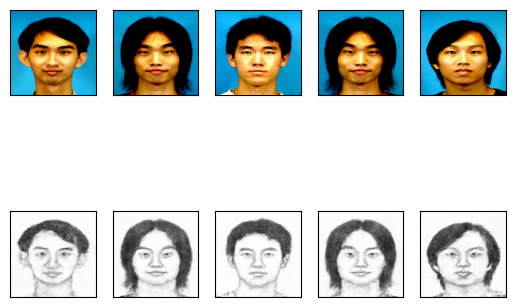

In [27]:
print(len(test_set))
temp_img_num = int(len(test_set)/2)
temp_img_num = 5

test_set1 = test_set.take(temp_img_num)
test_set2 = test_set.take(temp_img_num)

for step, (input_image, target_image) in test_set1.enumerate():
#     ax = plt.subplot(3,temp_img_num,int(step)+1)
    ax = plt.subplot(2,temp_img_num,int(step)+1)
    plt.imshow(input_image)
    plt.xticks([])
    plt.yticks([])
    
#     ax = plt.subplot(3,temp_img_num,temp_img_num+int(step)+1)
#     plt.imshow(target_image)
#     plt.xticks([])
#     plt.yticks([])
    
    gen_output = generator(input_image[tf.newaxis, ...], training=False)
#     ax = plt.subplot(3,temp_img_num,(temp_img_num*2)+int(step)+1)
    ax = plt.subplot(2,temp_img_num,temp_img_num+int(step)+1)
    
    gen_output = gen_output[0,...]
    denorm_output = denormalize(gen_output)
    denorm_output = tf.cast(denorm_output,tf.int32)
    denorm_output = tf.clip_by_value(denorm_output,0,255)

    plt.imshow(denorm_output)
    plt.xticks([])
    plt.yticks([])
    
#     if (step==0):
#         break


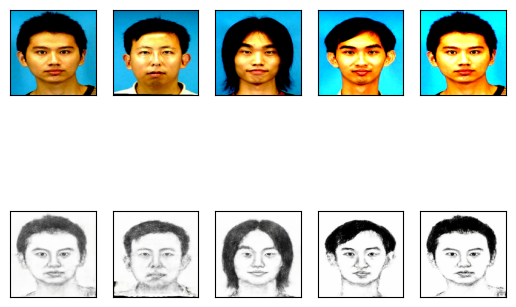

In [28]:
for step, (input_image, target_image) in test_set2.enumerate():
#     ax = plt.subplot(3,temp_img_num,int(step)+1)
    ax = plt.subplot(2,temp_img_num,int(step)+1)
    plt.imshow(input_image)
    plt.xticks([])
    plt.yticks([])
    
#     ax = plt.subplot(3,temp_img_num,temp_img_num+int(step)+1)
#     plt.imshow(target_image)
#     plt.xticks([])
#     plt.yticks([])
    
    gen_output = generator(input_image[tf.newaxis, ...], training=False)
#     ax = plt.subplot(3,temp_img_num,(temp_img_num*2)+int(step)+1)
    ax = plt.subplot(2,temp_img_num,temp_img_num+int(step)+1)
    
    gen_output = gen_output[0,...]
    denorm_output = denormalize(gen_output)
    denorm_output = tf.cast(denorm_output,tf.int32)
    denorm_output = tf.clip_by_value(denorm_output,0,255)

    plt.imshow(denorm_output)
    plt.xticks([])
    plt.yticks([])

In [29]:
generator.save("PortraitToSketch")